In [1]:
#Data Loading

import pandas as pd

df=pd.read_csv(r"C:\Users\User\Desktop\DATA SCIENCE ASSIGNMENTS\File\Natural language processing\amazonreviews.tsv", sep="\t")

df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [2]:
#Basic Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [3]:
df.shape

(10000, 2)

In [4]:
df.describe()

,label,review
count,10000,10000
unique,2,10000
top,neg,Early Hopkins story still sends chills through...
freq,5097,1


In [5]:
df.isnull().sum()

label     0
review    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
#Data Cleaning

import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [8]:
stop_words=set(stopwords.words("english"))

lemmatizer=WordNetLemmatizer()

def clean_text(text):

    text=text.lower()
    
    text=re.sub(r'http\S+', '',text)

    text=re.sub(r'[^a-zA-Z]', ' ',text)

    words=text.split()

    words=[lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

In [9]:
df["clean_review"]=df["review"].apply(clean_text)

In [10]:
#Label Encoding
#Convert
#Positive → 1
#Negative → 0

df["label"]=df["label"].map({
    "pos":1,
    "neg":0
})

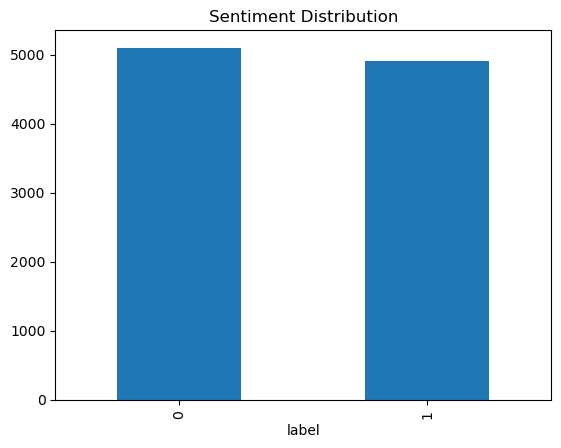

In [11]:
#Exploratory Data Analysis
#Sentiment Distribution

import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.show()

<Axes: >

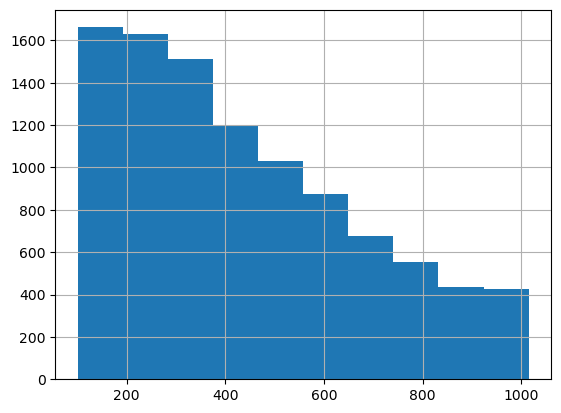

In [12]:
#Review Length

df["Review_Lenght"]=df["review"].apply(len)
df["Review_Lenght"].hist()

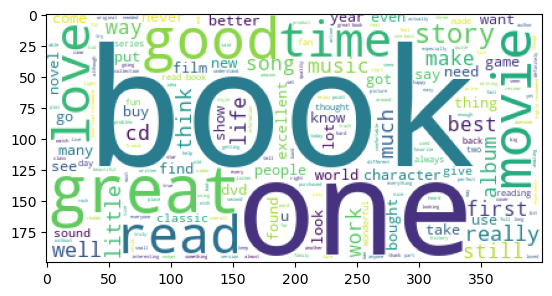

In [13]:
#Word Cloud (Positive)

from wordcloud import WordCloud

positive_text=" ".join(df[df.label==1]["clean_review"])

wordcloud=WordCloud(
    background_color="white"
).generate(positive_text)

plt.imshow(wordcloud)

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

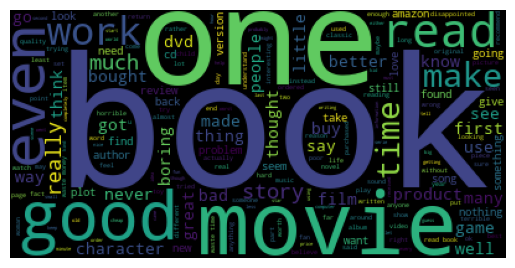

In [14]:
#Word Cloud (Negative)

negative_text= " ".join(df[df.label==0]["clean_review"])

wordcloud = WordCloud(
    background_color="black"
).generate(negative_text)

plt.imshow(wordcloud)
plt.axis("off")

In [15]:
#Most Frequent Words

from collections import Counter

words=" ".join(df.clean_review).split()
Counter(words).most_common(20)

[('book', 7693),
 ('one', 4190),
 ('movie', 3114),
 ('like', 2934),
 ('read', 2903),
 ('good', 2834),
 ('great', 2782),
 ('time', 2510),
 ('would', 2421),
 ('get', 2247),
 ('story', 1656),
 ('really', 1615),
 ('well', 1509),
 ('make', 1487),
 ('first', 1484),
 ('work', 1482),
 ('much', 1446),
 ('even', 1430),
 ('love', 1368),
 ('buy', 1279)]

In [16]:
#Train Test Split

from sklearn.model_selection import train_test_split

X=df["clean_review"]
y=df["label"]
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
#Feature Extraction (TF-IDF)

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf=TfidfVectorizer(max_features=5000)
X_train_tfidf=tfidf.fit_transform(X_train)
X_test_tfidf=tfidf.transform(X_test)

In [18]:
#Model Building
#Logistic Regression

from sklearn.linear_model import LogisticRegression

model=LogisticRegression()

model.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression()

In [19]:
pred=model.predict(X_test_tfidf)

In [20]:
#Support Vector Machine

from sklearn.svm import LinearSVC

svm=LinearSVC()

svm.fit(
    X_train_tfidf,
    y_train
)

LinearSVC()

In [21]:
pred_svm=svm.predict(X_test_tfidf)

In [22]:
#Naive Bayes

from sklearn.naive_bayes import MultinomialNB

nb=MultinomialNB()

nb.fit(
    X_train_tfidf,
    y_train
)

MultinomialNB()

In [23]:
pred_nb=nb.predict(X_test_tfidf)

In [24]:
#Model Evaluation

from sklearn.metrics import accuracy_score
accuracy_score(y_test,pred)

0.8475

In [25]:
#Confusion Matrix

from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,pred)

array([[888, 149],
       [156, 807]])

In [26]:
#Classification Report

from sklearn.metrics import classification_report
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.85      0.86      0.85      1037
           1       0.84      0.84      0.84       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



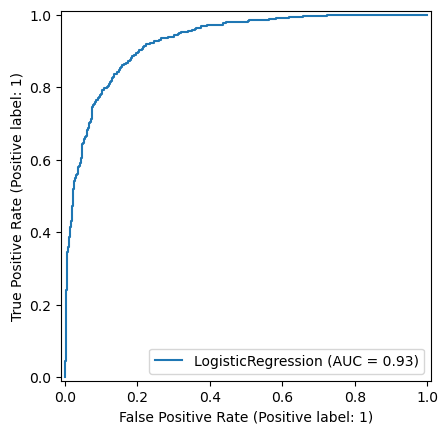

In [27]:
#ROC Curve

from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    model,
    X_test_tfidf,
    y_test
)

In [28]:
#Cross Validation

from sklearn.model_selection import cross_val_score

scores=cross_val_score(

    model,
    tfidf.fit_transform(X),
    y,
    cv=5
)

print(scores.mean())

0.8382999999999999


In [31]:
#Sample Prediction

reviews = [
    "This movie was fantastic. I loved every minute of it.",
    "Worst product I have ever bought.",
    "Excellent quality and fast delivery.",
    "Terrible experience. Waste of money."
]

for r in reviews:
    cleaned = clean_text(r)
    vector = tfidf.transform([cleaned])
    pred = model.predict(vector)[0]

    sentiment = "Positive 😊" if pred == 1 else "Negative 😞"

    print(f"Review: {r}")
    print(f"Prediction: {sentiment}")
    print("-"*50)

Review: This movie was fantastic. I loved every minute of it.
Prediction: Positive 😊
--------------------------------------------------
Review: Worst product I have ever bought.
Prediction: Positive 😊
--------------------------------------------------
Review: Excellent quality and fast delivery.
Prediction: Negative 😞
--------------------------------------------------
Review: Terrible experience. Waste of money.
Prediction: Negative 😞
--------------------------------------------------
